# 01 - Análisis Exploratorio
## Objetivo del análisis exploratorio
El análisis exploratorio de datos tiene como propósito comprender la estructura, calidad y comportamiento del dataset antes de la construcción de modelos.

Durante esta etapa se busca identificar:

- Valores nulos y posibles inconsistencias.
- Variables irrelevantes o redundantes.
- Distribuciones y patrones importantes.
- Presencia de outliers.
- Relaciones entre variables.
- Posibles factores asociados al abandono de clientes.

Este proceso resulta fundamental para garantizar que las etapas posteriores de limpieza, transformación y modelado se desarrollen sobre datos confiables y correctamente comprendidos.

Además,nos permite generar una primera interpretación del problema de negocio, facilitando la selección de variables relevantes y estrategias adecuadas para los modelos supervisados implementados posteriormente.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Carga del dataset original
# Actualización: el dataset está disponible localmente en la ruta data/raw/
DATA_URL = "https://raw.githubusercontent.com/monkIIlol/Repo-Programacion/main/data/dataset_clientes.csv"
DATA_FILE = os.path.join("data", "raw", "dataset_clientes.csv")

# Intentar localizar el dataset localmente o descargarlo si no existe
try:
    if os.path.exists(DATA_FILE):
        # Si ya existe el archivo, simplemente leerlo desde data/raw/
        data_raw = pd.read_csv(DATA_FILE)
    else:
        # Intentar crear la carpeta si no existe y descargar el archivo
        try:
            os.makedirs(os.path.dirname(DATA_FILE), exist_ok=True)
            import urllib.request
            print(f"Archivo '{DATA_FILE}' no encontrado localmente. Intentando descargar desde {DATA_URL} ...")
            urllib.request.urlretrieve(DATA_URL, DATA_FILE)
            print("Descarga completada.")
            data_raw = pd.read_csv(DATA_FILE)
        except Exception as error:
            # Como fallback adicional, intentar leer directamente desde la URL si la descarga falla
            print("No se pudo descargar el dataset automáticamente. Intentando leer directamente desde la URL...")
            try:
                data_raw = pd.read_csv(DATA_URL)
                # Guardar una copia local para usos posteriores, si es posible
                try:
                    os.makedirs(os.path.dirname(DATA_FILE), exist_ok=True)
                    data_raw.to_csv(DATA_FILE, index=False)
                    print("Lectura directa desde URL exitosa y archivo guardado localmente en data/raw/.")
                except Exception:
                    # Si no se puede guardar, continuamos con data_raw en memoria
                    print("Lectura directa desde URL exitosa, pero no se pudo guardar el archivo localmente.")
            except Exception as e2:
                print("No se pudo leer el dataset desde la URL tampoco.")
                print("Sube el archivo dataset_clientes.csv al directorio data/raw/ y vuelve a ejecutar esta celda.")
                raise e2
except FileNotFoundError as fnf_err:
    # Mensaje claro si por alguna razón el archivo no está disponible tras los intentos
    raise FileNotFoundError(
        "No se pudo acceder al archivo 'data/raw/dataset_clientes.csv'. Asegúrate de que el archivo exista en el directorio data/raw o que la URL sea accesible."
    ) from fnf_err

# Se mantiene `data` como copia de trabajo para que el EDA use el dataset original sin modificarlo.
data = data_raw.copy()

# Mostrar información básica para confirmar la carga
print("Shape:", data.shape)
print("Columnas:", list(data.columns))

Shape: (20400, 22)
Columnas: ['id_cliente', 'fecha_registro', 'edad', 'genero', 'region', 'estado_civil', 'ingreso_mensual', 'gasto_mensual', 'deuda_total', 'score_crediticio', 'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'uso_app', 'tipo_plan', 'num_productos', 'tiene_tarjeta_credito', 'canal_registro', 'dia_semana_registro', 'hora_registro', 'codigo_postal', 'abandono']


Carga de Datos desde Repositorio Local



In [2]:
data

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,4925,2021-08-09,47,Femenino,Centro,Divorciado,4.818457e+05,523321.283921,1.750852e+06,715.276140,...,39,Alto,Basico,1,0,Web,Viernes,4,5831,0
20396,1627,2021-10-26,18,Masculino,Sur,Divorciado,1.062000e+06,692112.449676,1.865442e+06,662.855074,...,319,Bajo,Premium,3,0,Web,Domingo,17,2925,0
20397,13007,2022-10-05,76,Femenino,Norte,Soltero,1.595617e+06,568544.699045,1.862204e+06,640.595219,...,325,Medio,Estandar,4,0,App,Viernes,16,1660,0
20398,17724,2020-01-10,23,Otro,Sur,Casado,8.056724e+05,348930.779211,2.032151e+06,466.372014,...,81,Bajo,Premium,2,0,Tienda,Lunes,14,4561,1


Se logra visualizar que el dataset contiene 20.400 registros y 22 columnas.

## Calidad de los datos

En esta etapa, necesitamos conocer nulos, duplicados e inconsistencias

### Necesitamos una vista estructural que nos permita conocer los tipos de datos y saber si hay nulos:

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu



Se observan distintos tipos de datos, incluyendo variables numéricas (enteras y decimales) y categóricas (tipo object).

Las variables numéricas corresponden a información cuantitativa como edad, ingresos y gasto, mientras que las variables categóricas representan características como género, región y tipo de plan.

Además, se identifican valores nulos en algunas variables, lo que indica la necesidad de realizar un proceso de limpieza de datos.

### **Eliminación de Variables de Identificación**

La eliminación de las columnas id_cliente y codigo_postal se realiza debido a que ambas actúan únicamente como identificadores artificiales que carecen de poder predictivo.

In [4]:
data.drop(columns=["id_cliente","codigo_postal"]).describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,abandono
count,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,0.396814
std,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,0.489249
min,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,0.000000
50%,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,0.000000
75%,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,1.000000
max,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,1.000000


### **Análisis de Nulos**

Se buscan valores nulos para evitar errores en el entrenamiento de modelos, definir una estrategia adecuada de limpieza o imputación de datos y prevenir sesgos que puedan afectar la precisión y el rendimiento del análisis.

In [5]:
data.isnull().sum()

id_cliente                  0
fecha_registro              0
edad                        0
genero                      0
region                      0
estado_civil                0
ingreso_mensual          1021
gasto_mensual            1025
deuda_total                 0
score_crediticio         1021
antiguedad_meses            0
frecuencia_compra           0
ultima_compra_dias          0
uso_app                     0
tipo_plan                   0
num_productos               0
tiene_tarjeta_credito       0
canal_registro              0
dia_semana_registro         0
hora_registro               0
codigo_postal               0
abandono                    0
dtype: int64

Los valores nulos muestran que la mayoría de las variables del dataset se encuentran completas, sin presencia de datos faltantes. Sin embargo, las variables ingreso_mensual, gasto_mensual y score_crediticio presentan registros nulos.Debido a que estas variables representan información financiera relevante para el análisis y la predicción del abandono, no es recomendable eliminar los registros afectados, ya que esto podría generar pérdida significativa de información y sesgo en el modelo.

Por cada columna que tenga valores **NaN** (ingreso_mensual, gasto_mensual, score_crediticio) vamos a calcular el porcentaje de nulos:

#### ingreso_mensual

In [6]:
print(f"porcentaje de nulos en ingreso_mensual: {data['ingreso_mensual'].isnull().sum().sum() / data['ingreso_mensual'].size * 100:.4f}%")

porcentaje de nulos en ingreso_mensual: 5.0049%


#### gasto_mensual

In [7]:
print(f"porcentaje de nulos en gasto_mensual: {data['gasto_mensual'].isnull().sum().sum() / data['gasto_mensual'].size * 100:.4f}%")

porcentaje de nulos en gasto_mensual: 5.0245%


#### score_crediticio

In [8]:
print(f"porcentaje de nulos en score_crediticio: {data['score_crediticio'].isnull().sum().sum() / data['score_crediticio'].size * 100:.4f}%")

porcentaje de nulos en score_crediticio: 5.0049%


#### Porcentajes total de nulos del DF.

In [9]:
print(f"porcentaje nulos en total: {data.isnull().sum().sum() / data.size * 100:.4f}%")

porcentaje nulos en total: 0.6834%


Se identifican valores nulos en las variables ingreso mensual, gasto mensual, y score crediticio. Estos valores faltantes representan aproximadamente un 5% del total de datos de su columna correspondiente, esto es bastante, por lo que se evaluará su tratamiento mediante imputación en lugar de eliminar registros, con el fin de no perder información relevante

### Buscamos Duplicados

Se realizó la detección de registros duplicados para validar la integridad del dataset, considerando que cada fila representa un cliente único:

In [10]:
data.duplicated().sum()

400

Se identificaron 400 registros duplicados en el dataset, lo que corresponde aproximadamente al 2% del total de datos.

Aunque el porcentaje no es elevado, La presencia de duplicados implica una sobre-representación al dar mayor peso a observaciones repetidas. Por ello, se eliminaron los duplicados para asegurar la validez y representatividad del análisis.

## Forma de los datos (análisis estadístico)

En esta etapa, debemos conocer la distribución de los datos y outliers, y sobre todo, analizar la variable más importante: **abandono**

### Necesitamos una vista estadística para tener una primera impresión de las Medidas de Tendencia Central, Medidas de Posición y sobre todo, la dispersión de los datos:

In [11]:
data.loc[:, ~data.columns.isin(['id_cliente', 'abandono'])].describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal
count,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,5488.970147
std,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,2602.374998
min,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1000.000000
25%,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,3239.000000
50%,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,5477.500000
75%,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,7775.000000
max,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,9998.000000


A partir de las estadísticas descriptivas, se analizan las variables numéricas considerando medidas como la media, mediana y valores extremos.
Se observan diferencias entre la media y la mediana en algunas variables, lo que puede indicar la presencia de valores atípicos (outliers).
Asimismo, se detectan valores negativos en variables financieras como ingreso mensual, gasto mensual y deuda total, lo cual representa una inconsistencia en los datos que deberá ser tratada en la etapa de limpieza.

### Buscamos Outliers

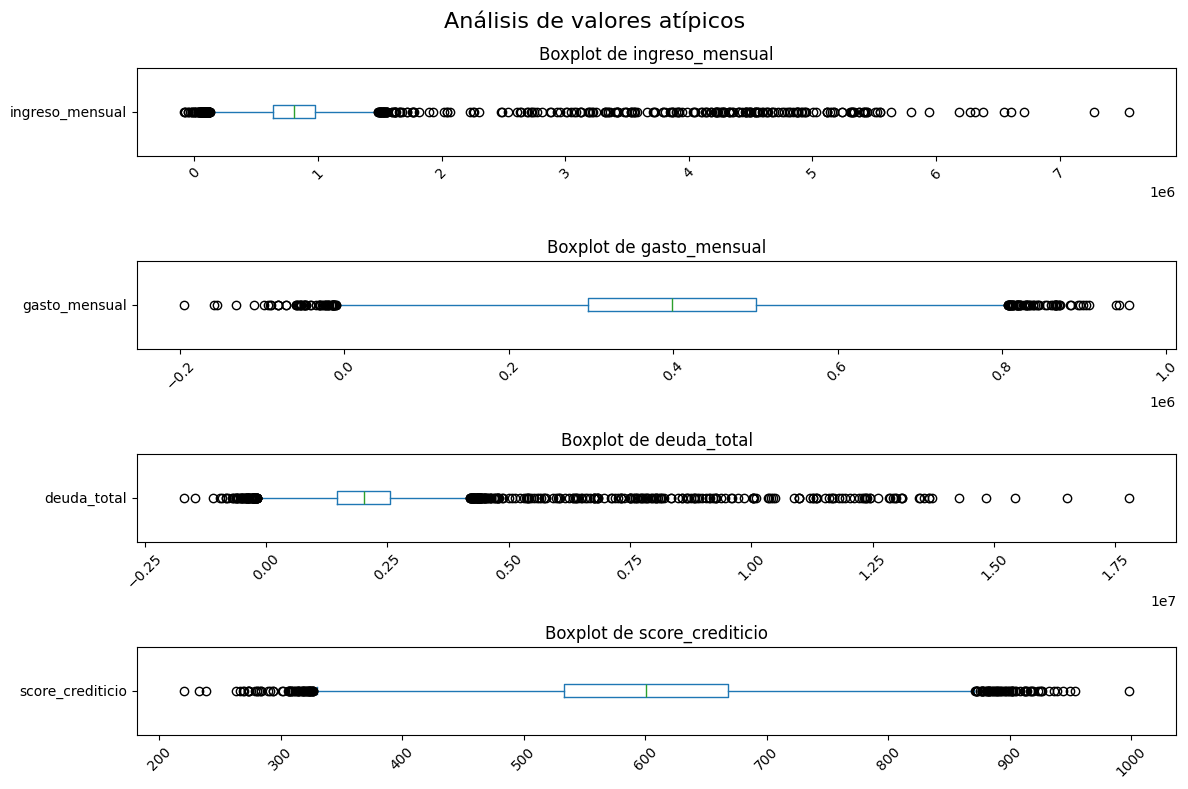

In [12]:
revision_atipicos = [
    'ingreso_mensual',
    'gasto_mensual',
    'deuda_total',
    'score_crediticio'
]


fig, axes = plt.subplots(len(revision_atipicos), 1, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(revision_atipicos):
    data[col].plot(kind='box', ax=axes[i], vert=False)
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de valores atípicos", fontsize=16)
plt.tight_layout()

plt.show()

A partir de este análisis, se identificaron valores atípicos en las variables financieras analizadas, lo que evidencia la presencia de datos extremos que podrían influir en el análisis y en el rendimiento de modelos predictivos.

Además, se detectaron valores negativos en estas variables, los cuales corresponden a inconsistencias en los datos más que a valores atípicos, ya que no son coherentes con la naturaleza de las variables estudiadas.

### Observamos la distribución de los datos

Se seleccionaron variables numéricas clave relacionadas con el comportamiento financiero y de consumo del cliente, ya que son las que pueden influir directamente en el abandono. Los histogramas permiten analizar su distribución, detectar sesgos y validar la presencia de valores atípicos identificados previamente

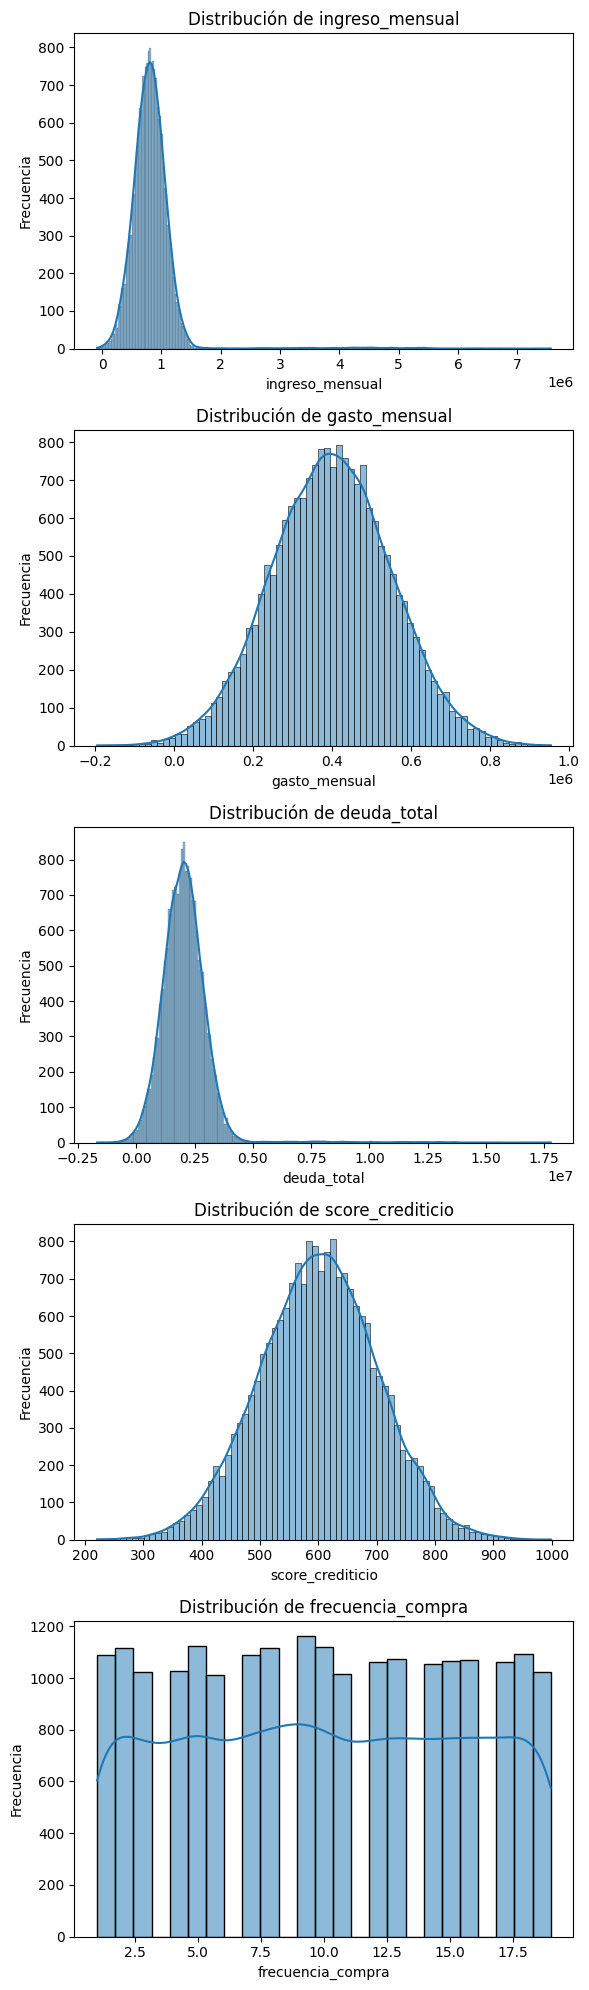

In [13]:
variables = [
    'ingreso_mensual',
    'gasto_mensual',
    'deuda_total',
    'score_crediticio',
    "frecuencia_compra"
]

num_columns = len(variables)
fig, axes = plt.subplots(num_columns, 1, figsize=(6, num_columns * 4))
axes = axes.flatten()

for i, col in enumerate(variables):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Se identificaron datos inconsistentes en variables financieras, específicamente valores negativos que no son coherentes con la naturaleza de las variables.

### Cantidad de valores negativos y porcentajes en cada variable:

In [14]:
cols_a_revisar = ['ingreso_mensual', 'gasto_mensual', 'deuda_total']

for col in cols_a_revisar:
    total_negativos = (data[col] < 0).sum()
    porcentaje = (total_negativos / len(data)) * 100
    print(f"{col}: {total_negativos} valores negativos ({porcentaje:.2f}%)")

ingreso_mensual: 11 valores negativos (0.05%)
gasto_mensual: 68 valores negativos (0.33%)
deuda_total: 143 valores negativos (0.70%)


### Correlación con la variable target: abandono

Se analiza la distribución de la variable objetivo “abandono” para comprender si existe un desbalance, lo cual puede influir en el análisis posterior y en la construcción de modelos:

In [15]:
data['abandono'].value_counts(normalize=True) * 100

abandono
0    60.318627
1    39.681373
Name: proportion, dtype: float64

A primera vista, vemos un desbalance:

- 60% para 0,
- 40% para 1

La variable objetivo presenta una distribución de aproximadamente 60% de clientes que permanecen y 40% que abandonan. Esto indica un nivel relevante de cancelación del servicio, lo que justifica el análisis de las variables que podrían explicar este comportamiento.

Se comparan las medias y medianas (segun correspondan en base a la distribución que hicimos anteriormente a estas variables) de variables numéricas según el estado de abandono, con el fin de identificar diferencias en el comportamiento financiero y de consumo entre los clientes que abandonan y los que permanecen.

Para:


*   gasto_mensual
*   score_crediticio
*   frecuencia_compra

la **media** es representativa, ya que presentan una distribución simétrica




In [16]:
data.groupby("abandono")[[
    "gasto_mensual",
    "score_crediticio",
    "frecuencia_compra"
]].mean()

,gasto_mensual,score_crediticio,frecuencia_compra
abandono,,,
0,400481.607762,602.786962,10.163104
1,397885.871364,596.881946,9.668314


Se observa que los clientes que abandonan presentan un menor gasto mensual, menor score crediticio y menor frecuencia de compra.
Aunque las diferencias no son grandes, se identifica un patrón consistente de menor actividad y peor perfil financiero en los clientes que abandonan.

Para:


*   ingreso_mensual
    
*   deuda_total

la **mediana** es representativa, ya que ingreso_mensual está sesgada hacia la derecha, tiene una cola larga(outliers), lo mismo con deuda_total.



In [17]:
data.groupby("abandono")[[
    "ingreso_mensual",
    "deuda_total",

]].median()

,ingreso_mensual,deuda_total
abandono,,
0,801627.436140,1.992320e+06
1,807804.664315,2.046122e+06


Se observa que los clientes que abandonan presentan una mayor deuda total, lo que sugiere una posible relación entre carga financiera y abandono.
En cambio, el ingreso mensual no muestra diferencias relevantes, por lo que no sería un factor determinante.

Se analiza la relación entre el tipo de plan, uso de la app y el abandono mediante una tabla de contingencia, con el objetivo de identificar si ciertos planes presentan mayor proporción de cancelación:

In [18]:
pd.crosstab(data["tipo_plan"], data["abandono"], normalize="index") * 100

abandono,0,1
tipo_plan,,
Basico,53.783784,46.216216
Estandar,63.230590,36.769410
Premium,63.742349,36.257651


A partir del análisis del tipo de plan, se observa que los clientes con plan básico presentan una mayor proporción de abandono en comparación con los planes estándar y premium. Esto sugiere que los planes de menor valor podrían estar asociados a una menor fidelización, ya sea por menor percepción de beneficio o menor compromiso con el servicio.

In [19]:
pd.crosstab(data["uso_app"], data["abandono"], normalize="index") * 100

abandono,0,1
uso_app,,
Alto,66.784296,33.215704
Bajo,47.400523,52.599477
Medio,67.019216,32.980784


En relación con el uso de la aplicación, se observa una diferencia significativa en el comportamiento de los clientes. Aquellos con un bajo nivel de uso presentan una mayor proporción de abandono, superando incluso a los clientes que permanecen en el servicio. En contraste, los clientes con uso medio y alto muestran una menor tasa de cancelación. Esto indica que el nivel de interacción con la plataforma es un factor clave en la retención de clientes.

Se analizan las relaciones entre variables numéricas y la variable abandono mediante correlaciones de Pearson y Spearman, con el fin de identificar dependencias lineales y monotónicas que puedan explicar el comportamiento de los clientes:

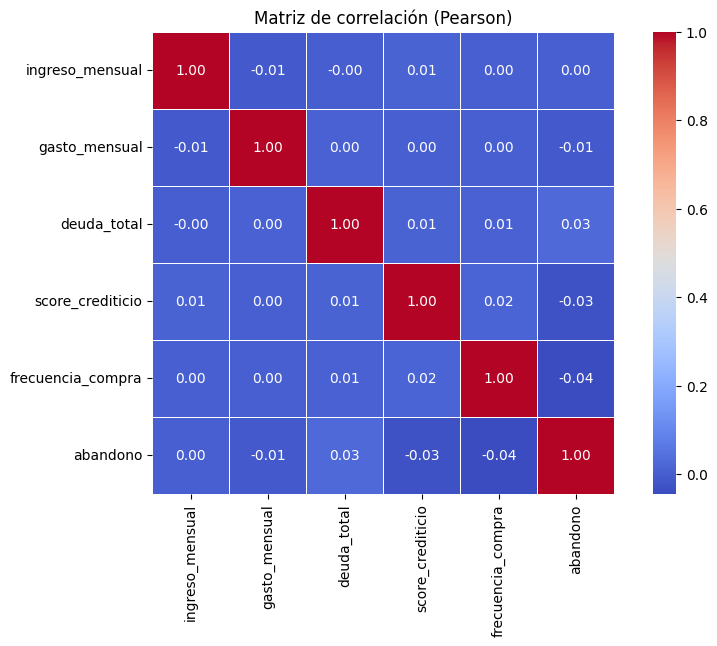

In [20]:
cols_corr = [
    "ingreso_mensual",
    "gasto_mensual",
    "deuda_total",
    "score_crediticio",
    "frecuencia_compra",
    "abandono"
]

corr_pearson = data[cols_corr].corr(method="pearson")

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Matriz de correlación (Pearson)")
plt.show()

La matriz de correlación de Pearson muestra que las variables numéricas presentan valores cercanos a cero en relación con la variable abandono, lo que indica la ausencia de relaciones lineales significativas. Esto sugiere que ninguna variable, por sí sola, explica directamente el abandono de los clientes, reforzando la idea de que se trata de un fenómeno multifactorial.

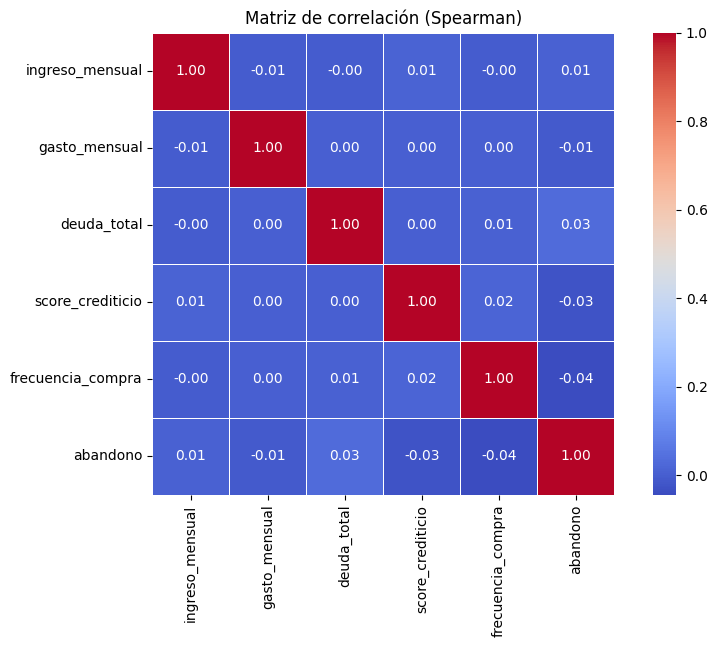

In [21]:
corr_spearman = data[cols_corr].corr(method="spearman")

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Matriz de correlación (Spearman)")
plt.show()

La correlación de Spearman presenta resultados similares a los obtenidos con Pearson, evidenciando también relaciones débiles entre las variables numéricas y el abandono. Esto indica que no existen relaciones monotónicas fuertes, lo que sugiere que el abandono no depende de patrones simples, sino de interacciones más complejas entre variables.

## Cierre del EDA

El análisis exploratorio permitió comprender la estructura general del dataset e identificar aspectos relevantes para las etapas posteriores del proyecto.
Durante el proceso se detectaron valores nulos,duplicados,inconsistencia,outliers, variables con distintos niveles de correlación y patrones asociados al abandono de clientes.
Asimismo, el análisis estadístico y visual permitió obtener una mejor comprensión del comportamiento de las variables numéricas y categóricas, facilitando la toma de decisiones respecto al preprocesamiento y selección de características.
Los hallazgos obtenidos en esta etapa sirvieron como base para las tareas de limpieza, transformación y modelado supervisado desarrolladas en los notebooks posteriores.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a797108b-ff37-4667-9d30-00c3227a6ce3' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>